## Data

In [1]:
import pandas as pd

blueprinty = pd.read_csv('blueprinty.csv')
blueprinty.head()

,patents,region,age,iscustomer
0,0,Midwest,32.5,0
1,3,Southwest,37.5,0
2,4,Northwest,27.0,1
3,3,Northeast,24.5,0
4,3,Southwest,37.0,0


iscustomer
0    3.473013
1    4.133056
Name: patents, dtype: float64

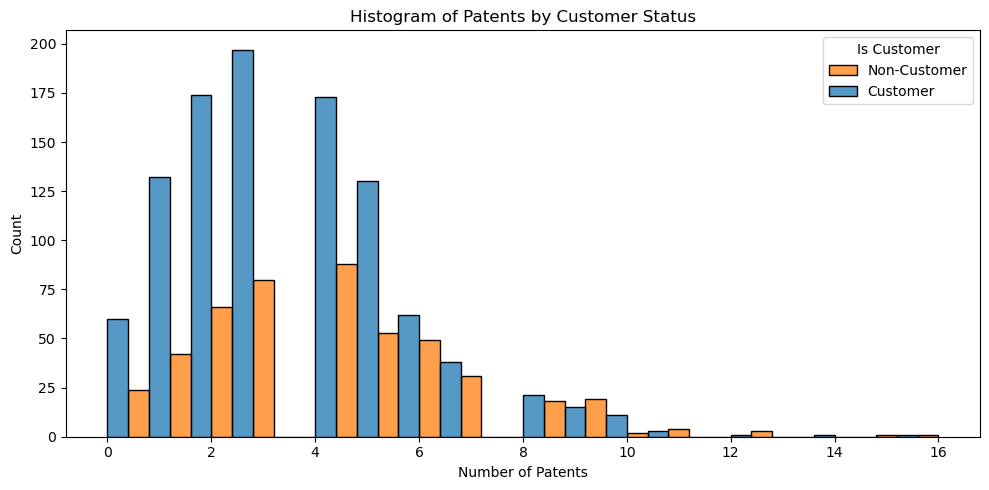

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute mean number of patents by customer status
mean_patents = blueprinty.groupby("iscustomer")["patents"].mean()

# Plot histogram of number of patents by customer status
plt.figure(figsize=(10, 5))
sns.histplot(data=blueprinty, x="patents", hue="iscustomer", multiple="dodge", bins=20)
plt.title("Histogram of Patents by Customer Status")
plt.xlabel("Number of Patents")
plt.ylabel("Count")
plt.legend(title="Is Customer", labels=["Non-Customer", "Customer"])
plt.tight_layout()

mean_patents


iscustomer,0,1
region,,
Midwest,83.5,16.5
Northeast,45.4,54.6
Northwest,84.5,15.5
South,81.7,18.3
Southwest,82.5,17.5


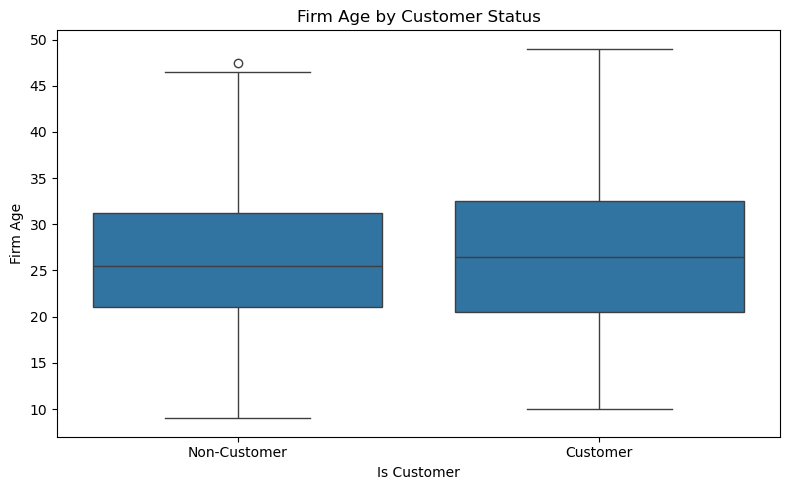

In [3]:
# Boxplot for firm age by customer status
plt.figure(figsize=(8, 5))
sns.boxplot(x="iscustomer", y="age", data=blueprinty)
plt.title("Firm Age by Customer Status")
plt.xlabel("Is Customer")
plt.ylabel("Firm Age")
plt.xticks([0, 1], ["Non-Customer", "Customer"])
plt.tight_layout()

# Crosstab for region by customer status
region_customer_crosstab = pd.crosstab(blueprinty["region"], blueprinty["iscustomer"], normalize='index') * 100
region_customer_crosstab.round(1)


## Estimation of Simple Poisson Model

In [4]:
import numpy as np
from scipy.special import gammaln

def poisson_loglikelihood(lmbda, Y):
    """
    Computes the negative log-likelihood of a Poisson model with scalar lambda.
    This is suitable for optimization routines like scipy.optimize.minimize.
    
    Parameters:
        lmbda : float
            The Poisson rate parameter (λ), must be > 0.
        Y : array-like
            Observed count data (e.g., number of patents).

    Returns:
        float : negative log-likelihood
    """
    if lmbda <= 0:
        return np.inf  # avoid invalid log(λ) or exp(−λ)
    
    Y = np.asarray(Y)
    log_lik = np.sum(Y * np.log(lmbda) - lmbda - gammaln(Y + 1))
    return log_lik  


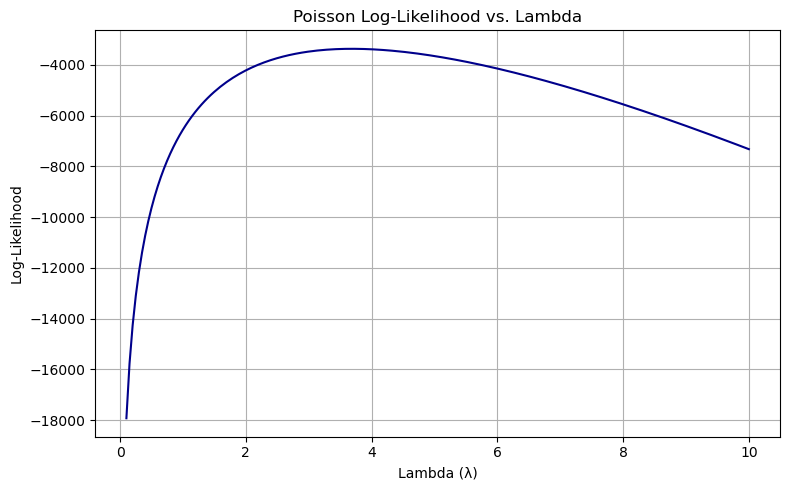

In [5]:
import matplotlib.pyplot as plt

Y = blueprinty["patents"].values

lambda_vals = np.linspace(0.1, 10, 200)
loglik_vals = [poisson_loglikelihood(lmb, Y) for lmb in lambda_vals]

plt.figure(figsize=(8, 5))
plt.plot(lambda_vals, loglik_vals, color='darkblue')
plt.title("Poisson Log-Likelihood vs. Lambda")
plt.xlabel("Lambda (λ)")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
from scipy.optimize import minimize

# Define the negative log-likelihood for use with optimizer
def neg_poisson_loglikelihood(lmbda, Y):
    if lmbda <= 0:
        return np.inf
    return -poisson_loglikelihood(lmbda, Y)

# Use the same Y from earlier
Y = blueprinty["patents"].values

# Use scipy to minimize the negative log-likelihood
result = minimize(fun=neg_poisson_loglikelihood, x0=[1.0], args=(Y,), bounds=[(1e-6, None)])
lambda_mle = result.x[0]
lambda_mle

3.6846667021660804

## Estimation of Poisson Regression Model

In [16]:
import numpy as np
from scipy.special import gammaln

# Define Poisson log-likelihood function (negative, stabilized)
def poisson_regression_loglik(beta, Y, X):
    eta = X @ beta
    eta = np.clip(eta, -20, 20)        # Prevent overflow in exp()
    lam = np.exp(eta)
    log_lik = np.sum(Y * eta - lam - gammaln(Y + 1))
    return -log_lik                   # Return negative for minimizer


In [17]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln
import patsy

# Create design matrix with intercept, age, age², region dummies, and customer
y, X = patsy.dmatrices('patents ~ age + I(age**2) + C(region) + iscustomer', data=blueprinty, return_type='dataframe')
Y = y.values.flatten()  # Convert y to 1D

# Initial guess for beta
beta0 = np.zeros(X.shape[1])

# Optimize the likelihood
result = minimize(poisson_regression_loglik, beta0, args=(Y, X), method='BFGS')

# Extract MLE estimates and standard errors
beta_hat = result.x
hessian_inv = result.hess_inv
standard_errors = np.sqrt(np.diag(hessian_inv))

# Present results in table
results_df = pd.DataFrame({
    "Coefficient": beta_hat,
    "Std. Error": standard_errors
}, index=X.columns)

print(results_df.round(4))


                        Coefficient  Std. Error
Intercept                   -0.5100      0.1931
C(region)[T.Northeast]       0.0292      0.0468
C(region)[T.Northwest]      -0.0176      0.0572
C(region)[T.South]           0.0566      0.0562
C(region)[T.Southwest]       0.0506      0.0497
age                          0.1487      0.0145
I(age ** 2)                 -0.0030      0.0003
iscustomer                   0.2076      0.0329


In [13]:
import statsmodels.api as sm

# Fit Poisson GLM with log link
glm_model = sm.GLM(Y, X, family=sm.families.Poisson())
glm_results = glm_model.fit()

# Display summary table
print(glm_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 1500
Model:                            GLM   Df Residuals:                     1492
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3258.1
Date:                Sun, 04 May 2025   Deviance:                       2143.3
Time:                        17:40:46   Pearson chi2:                 2.07e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1360
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

In [18]:
# Create two counterfactual design matrices:
# - X_0: assumes all firms are non-customers (iscustomer = 0)
# - X_1: assumes all firms are customers (iscustomer = 1)
X_0 = X.copy()
X_1 = X.copy()

X_0["iscustomer"] = 0
X_1["iscustomer"] = 1

# Predict expected number of patents under both scenarios
y_pred_0 = np.exp(X_0 @ beta_hat)
y_pred_1 = np.exp(X_1 @ beta_hat)

# Compute difference and average effect
diff = y_pred_1 - y_pred_0
average_effect = diff.mean()

print(f"Average treatment effect of Blueprinty's software: {average_effect:.4f} additional patents")


Average treatment effect of Blueprinty's software: 0.7928 additional patents


# AirBnB Case Study

In [14]:
import pandas as pd

airbnb = pd.read_csv('airbnb.csv')

In [8]:
# Step 1: Explore structure
print(airbnb.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40628 entries, 0 to 40627
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 40628 non-null  int64  
 1   id                         40628 non-null  int64  
 2   days                       40628 non-null  int64  
 3   last_scraped               40628 non-null  object 
 4   host_since                 40593 non-null  object 
 5   room_type                  40628 non-null  object 
 6   bathrooms                  40468 non-null  float64
 7   bedrooms                   40552 non-null  float64
 8   price                      40628 non-null  int64  
 9   number_of_reviews          40628 non-null  int64  
 10  review_scores_cleanliness  30433 non-null  float64
 11  review_scores_location     30374 non-null  float64
 12  review_scores_value        30372 non-null  float64
 13  instant_bookable           40628 non-null  obj

In [12]:
print("\nMissing values per column:\n")
print(airbnb.isnull().sum())


Missing values per column:

Unnamed: 0                       0
id                               0
days                             0
last_scraped                     0
host_since                      35
room_type                        0
bathrooms                      160
bedrooms                        76
price                            0
number_of_reviews                0
review_scores_cleanliness    10195
review_scores_location       10254
review_scores_value          10256
instant_bookable                 0
dtype: int64


In [13]:
print("\nFirst few rows:\n")
airbnb.head()


First few rows:



,Unnamed: 0,id,days,last_scraped,host_since,room_type,bathrooms,bedrooms,price,number_of_reviews,review_scores_cleanliness,review_scores_location,review_scores_value,instant_bookable
0,1,2515,3130,4/2/2017,9/6/2008,Private room,1.0,1.0,59,150,9.0,9.0,9.0,f
1,2,2595,3127,4/2/2017,9/9/2008,Entire home/apt,1.0,0.0,230,20,9.0,10.0,9.0,f
2,3,3647,3050,4/2/2017,11/25/2008,Private room,1.0,1.0,150,0,NaN,NaN,NaN,f
3,4,3831,3038,4/2/2017,12/7/2008,Entire home/apt,1.0,1.0,89,116,9.0,9.0,9.0,f
4,5,4611,3012,4/2/2017,1/2/2009,Private room,NaN,1.0,39,93,9.0,8.0,9.0,t


In [ ]:
# Drop rows with missing values in key predictors
airbnb_clean = airbnb.dropna(subset=[
    "bathrooms",
    "bedrooms",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value"
])

# Convert categorical variables
airbnb_clean["instant_bookable"] = airbnb_clean["instant_bookable"].map({"t": 1, "f": 0})

# One-hot encode room_type, drop one category to avoid multicollinearity
room_dummies = pd.get_dummies(airbnb_clean["room_type"], prefix="room", drop_first=True)

# Construct design matrix
X = pd.concat([
    airbnb_clean[[
        "price",
        "bedrooms",
        "bathrooms",
        "review_scores_cleanliness",
        "review_scores_location",
        "review_scores_value",
        "instant_bookable"
    ]],
    room_dummies
], axis=1)

# Add intercept manually
X.insert(0, "intercept", 1)

# Define target variable
Y = airbnb_clean["number_of_reviews"].values

# Show dimensions for confirmation
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (30160, 10)
Y shape: (30160,)


/tmp/ipykernel_7096/1035868469.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airbnb_clean["instant_bookable"] = airbnb_clean["instant_bookable"].map({"t": 1, "f": 0})


In [22]:
import statsmodels.api as sm

# Ensure all columns in X are numeric
X = X.astype(float)

# Fit the Poisson regression model
poisson_model = sm.GLM(Y, X, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

# View the results
print(poisson_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                30160
Model:                            GLM   Df Residuals:                    30150
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.2900e+05
Date:                Mon, 05 May 2025   Deviance:                   9.3653e+05
Time:                        11:28:24   Pearson chi2:                 1.41e+06
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5649
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
intercept             

# HW3 Python Code

In [17]:
import pandas as pd

df = pd.read_csv('conjoint_data.csv')
df.head()

,resp,task,choice,brand,ad,price
0,1,1,1,N,Yes,28
1,1,1,0,H,Yes,16
2,1,1,0,P,Yes,16
3,1,2,0,N,Yes,32
4,1,2,1,P,Yes,16


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   resp    3000 non-null   int64 
 1   task    3000 non-null   int64 
 2   choice  3000 non-null   int64 
 3   brand   3000 non-null   object
 4   ad      3000 non-null   object
 5   price   3000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 140.8+ KB


In [19]:
# One-hot encode brand and ad
df_encoded = pd.get_dummies(df, columns=['brand', 'ad'], drop_first=True)

# Sort and reset index
df_encoded = df_encoded.sort_values(by=['resp', 'task']).reset_index(drop=True)

# Verify that each task has 3 rows (alternatives)
task_counts = df_encoded.groupby(['resp', 'task']).size()
assert (task_counts == 3).all(), "Each task should have 3 alternatives"

df_encoded.head()

,resp,task,choice,price,brand_N,brand_P,ad_Yes
0,1,1,1,28,True,False,True
1,1,1,0,16,False,False,True
2,1,1,0,16,False,True,True
3,1,2,0,32,True,False,True
4,1,2,1,16,False,True,True


In [20]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

# Load and encode
df = pd.read_csv("conjoint_data.csv")
df_encoded = pd.get_dummies(df, columns=['brand', 'ad'], drop_first=True)
df_encoded = df_encoded.sort_values(by=['resp', 'task']).reset_index(drop=True)

# Convert booleans to floats (important!)
X = df_encoded[['brand_N', 'brand_P', 'ad_Yes', 'price']].astype(float).values
y = df_encoded['choice'].values

# Reshape to choice-task format
n_alternatives = 3
n_obs = len(y) // n_alternatives
X_grouped = X.reshape((n_obs, n_alternatives, -1))
y_grouped = y.reshape((n_obs, n_alternatives))

# Negative log-likelihood function
def neg_log_likelihood(beta):
    ll = 0
    for i in range(n_obs):
        utilities = X_grouped[i] @ beta
        probs = np.exp(utilities) / np.sum(np.exp(utilities))
        ll += np.log(probs[y_grouped[i] == 1][0])
    return -ll

# Initial guess and estimation
initial_beta = np.zeros(X.shape[1])
result = minimize(neg_log_likelihood, initial_beta, method='BFGS')

# Extract results
beta_hat = result.x
hessian_inv = result.hess_inv
standard_errors = np.sqrt(np.diag(hessian_inv))
ci_lower = beta_hat - 1.96 * standard_errors
ci_upper = beta_hat + 1.96 * standard_errors

# Summary
summary_df = pd.DataFrame({
    'Coefficient': beta_hat,
    'Std. Error': standard_errors,
    '95% CI Lower': ci_lower,
    '95% CI Upper': ci_upper
}, index=['brand_N', 'brand_P', 'ad_Yes', 'price'])

print(summary_df)


         Coefficient  Std. Error  95% CI Lower  95% CI Upper
brand_N     0.941195    0.018302      0.905323      0.977068
brand_P     0.501616    0.004777      0.492252      0.510979
ad_Yes     -0.731994    0.004563     -0.740938     -0.723051
price      -0.099480    0.005067     -0.109413     -0.089548


In [21]:
import pandas as pd
import numpy as np

# Log-prior: N(0, 0.05^2) for binary vars, N(0, 0.005^2) for price
def log_prior(beta):
    prior_sd = np.array([0.05, 0.05, 0.05, 0.005])
    return -0.5 * np.sum((beta / prior_sd)**2) - np.sum(np.log(prior_sd * np.sqrt(2 * np.pi)))

# Log-posterior
def log_posterior(beta):
    return -neg_log_likelihood(beta) + log_prior(beta)

# MCMC sampler
def metropolis_sampler(log_post, initial, n_samples=3000, proposal_sd=[0.05, 0.05, 0.05, 0.005]):
    samples = [initial]
    current_log_post = log_post(initial)
    np.random.seed(0)
    for _ in range(n_samples - 1):
        proposal = samples[-1] + np.random.normal(scale=proposal_sd)
        proposal_log_post = log_post(proposal)
        log_accept_ratio = proposal_log_post - current_log_post
        if np.log(np.random.rand()) < log_accept_ratio:
            samples.append(proposal)
            current_log_post = proposal_log_post
        else:
            samples.append(samples[-1])
    return np.array(samples)

# Run it
initial_beta = np.zeros(X.shape[1])
mcmc_samples = metropolis_sampler(log_posterior, initial_beta)

# Discard burn-in
mcmc_samples = mcmc_samples[1000:]

# Posterior summary
posterior_means = mcmc_samples.mean(axis=0)
posterior_sds = mcmc_samples.std(axis=0)
posterior_ci_lower = np.percentile(mcmc_samples, 2.5, axis=0)
posterior_ci_upper = np.percentile(mcmc_samples, 97.5, axis=0)

posterior_summary = pd.DataFrame({
    "Posterior Mean": posterior_means,
    "Posterior SD": posterior_sds,
    "95% CI Lower": posterior_ci_lower,
    "95% CI Upper": posterior_ci_upper
}, index=['brand_N', 'brand_P', 'ad_Yes', 'price'])

print(posterior_summary)


         Posterior Mean  Posterior SD  95% CI Lower  95% CI Upper
brand_N        0.150717      0.047870      0.064154      0.248803
brand_P        0.024741      0.040724     -0.059125      0.104080
ad_Yes        -0.182542      0.043102     -0.265188     -0.092351
price         -0.041593      0.003704     -0.049004     -0.034733


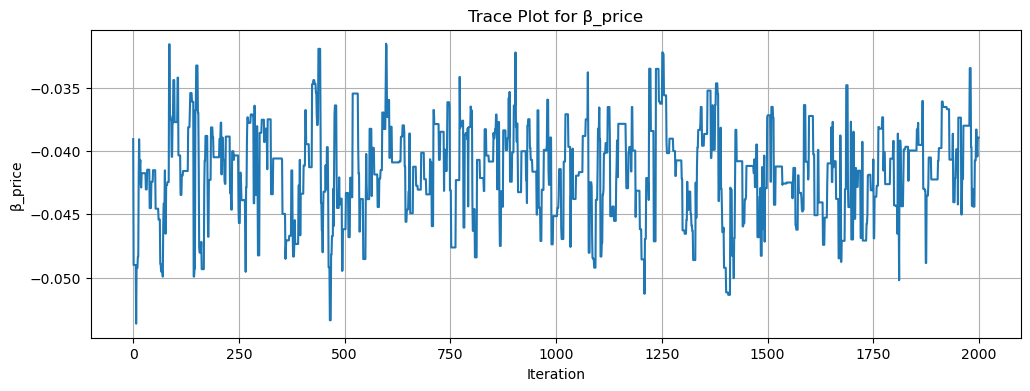

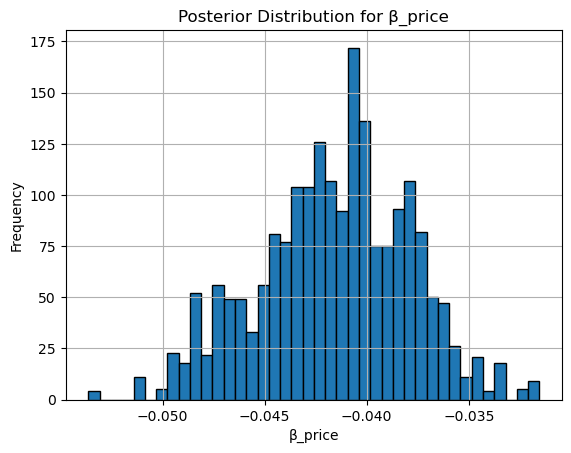

In [22]:
import matplotlib.pyplot as plt

# Trace plot for price
plt.figure(figsize=(12, 4))
plt.plot(mcmc_samples[:, 3])
plt.title("Trace Plot for β_price")
plt.xlabel("Iteration")
plt.ylabel("β_price")
plt.grid(True)
plt.show()

# Histogram for price
plt.hist(mcmc_samples[:, 3], bins=40, edgecolor='black')
plt.title("Posterior Distribution for β_price")
plt.xlabel("β_price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# HW4 Python Code

# 1a

In [14]:
import pandas as pd

penguins = pd.read_csv('palmer_penguins.csv')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
1,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
2,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
3,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
4,Adelie,Torgersen,39.3,20.6,190,3650,male,2007


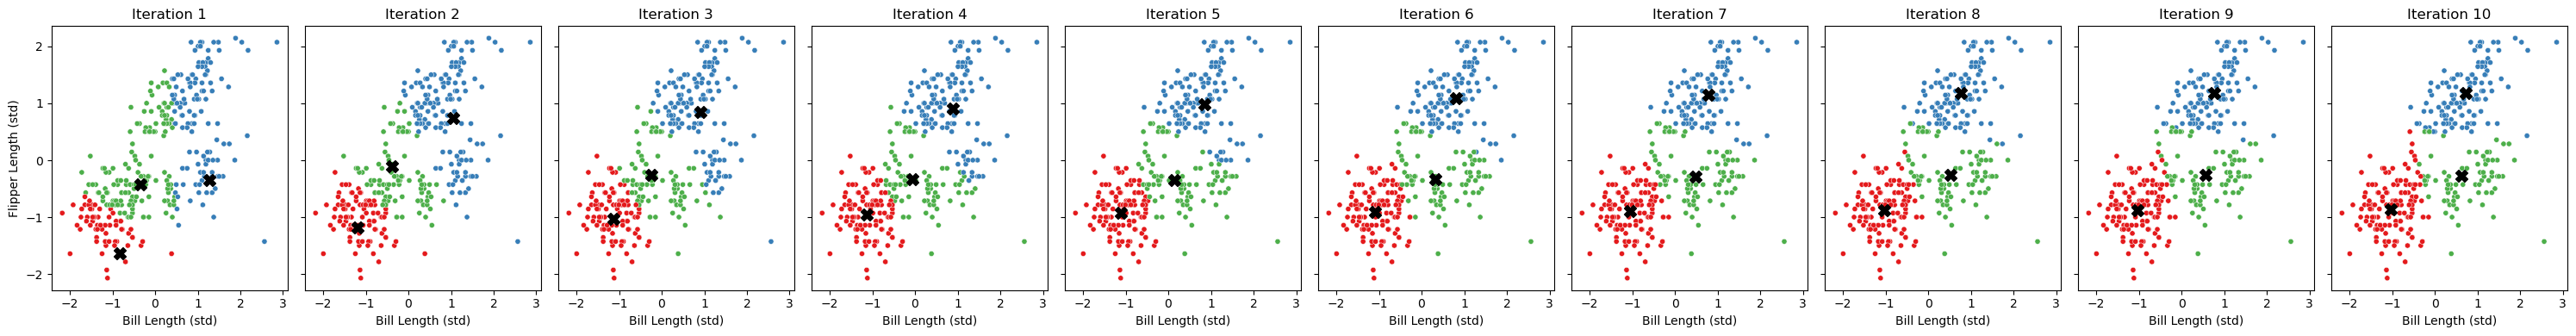

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Load and clean the data
penguins = pd.read_csv("palmer_penguins.csv")
penguins = penguins.dropna()

# Use only the selected features
features = ['bill_length_mm', 'flipper_length_mm']
X = penguins[features].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Manual K-Means with internal iteration tracking
def manual_kmeans_with_plot(X, k=3, max_iters=10, seed=42):
    np.random.seed(seed)
    n_samples = X.shape[0]
    centroids = X[np.random.choice(n_samples, k, replace=False)]
    history = []

    for iteration in range(max_iters):
        # Assign labels
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Save current state
        history.append((centroids.copy(), labels.copy()))

        # Update centroids
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return history

# Run K-Means and capture all iterations
history = manual_kmeans_with_plot(X_scaled, k=3, max_iters=10)

# Plot all iterations in a single row
def plot_kmeans_iterations(history, X_scaled):
    n_iter = len(history)
    fig, axes = plt.subplots(1, n_iter, figsize=(n_iter * 3, 4), sharex=True, sharey=True)

    for i, (centroids, labels) in enumerate(history):
        ax = axes[i]
        sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette="Set1", ax=ax, legend=False, s=20)
        ax.scatter(centroids[:, 0], centroids[:, 1], c='black', s=100, marker='X')
        ax.set_title(f"Iteration {i+1}")
        ax.set_xlabel("Bill Length (std)")
        if i == 0:
            ax.set_ylabel("Flipper Length (std)")
        else:
            ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

# Call the plot function
plot_kmeans_iterations(history, X_scaled)


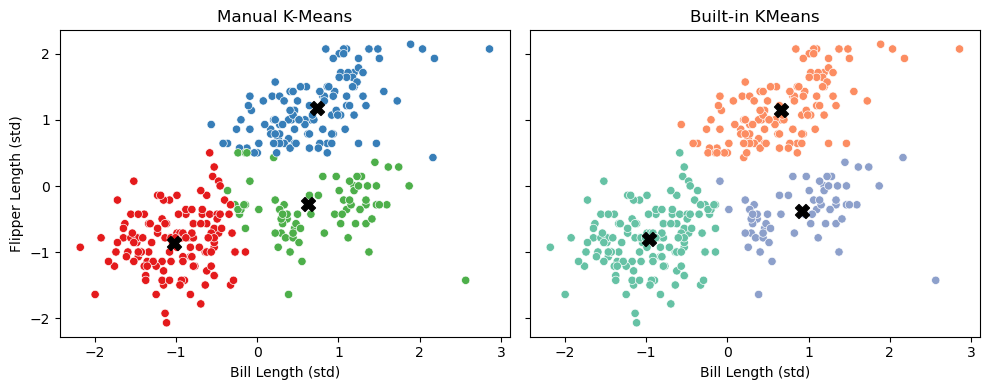

In [16]:
# Import the built-in KMeans from scikit-learn
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Run built-in KMeans on the same standardized data
kmeans_builtin = KMeans(n_clusters=3, random_state=42, n_init=10)
builtin_labels = kmeans_builtin.fit_predict(X_scaled)

# Plot comparison: manual vs. built-in
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

# Manual KMeans (last iteration)
centroids_manual, labels_manual = history[-1]

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_manual, palette="Set1", ax=axes[0], legend=False)
axes[0].scatter(centroids_manual[:, 0], centroids_manual[:, 1], c='black', s=100, marker='X')
axes[0].set_title("Manual K-Means")
axes[0].set_xlabel("Bill Length (std)")
axes[0].set_ylabel("Flipper Length (std)")

# Built-in KMeans
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=builtin_labels, palette="Set2", ax=axes[1], legend=False)
axes[1].scatter(kmeans_builtin.cluster_centers_[:, 0], kmeans_builtin.cluster_centers_[:, 1], c='black', s=100, marker='X')
axes[1].set_title("Built-in KMeans")
axes[1].set_xlabel("Bill Length (std)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


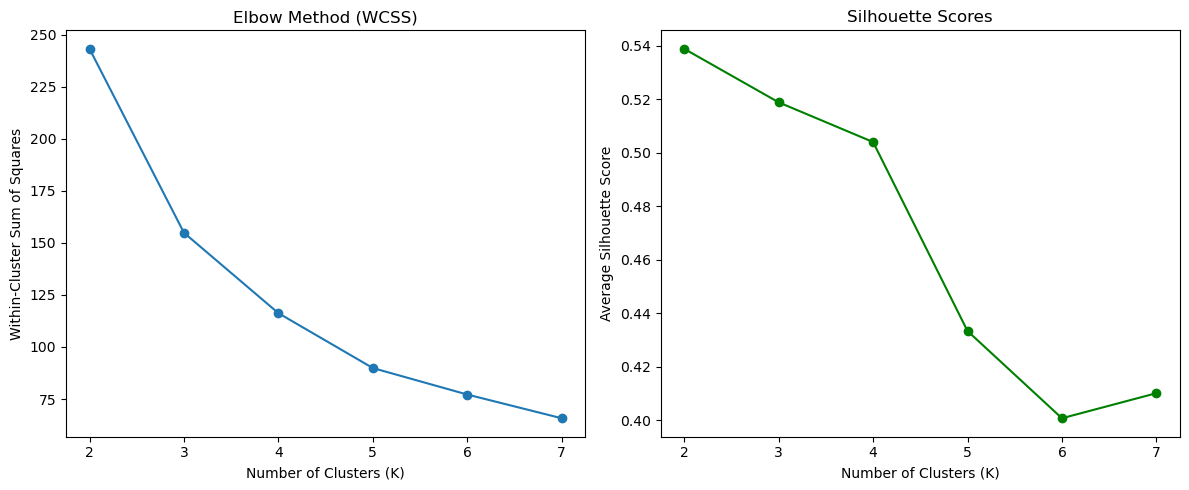

In [17]:
from sklearn.metrics import silhouette_score

# Evaluate WCSS and Silhouette for K = 2 to 7
wcss = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot both metrics side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# WCSS plot
axes[0].plot(K_range, wcss, marker='o')
axes[0].set_title("Elbow Method (WCSS)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares")

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, marker='o', color='green')
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Average Silhouette Score")

plt.tight_layout()
plt.show()


# 2b

In [23]:
import pandas as pd

drivers = pd.read_csv("data_for_drivers_analysis.csv")

# Calculate Pearson correlations between satisfaction and each predictor
# Drop ID and brand columns
correlations = drivers.corr(numeric_only=True)['satisfaction'].drop(['satisfaction', 'id', 'brand'])

# Create DataFrame with Pearson r and r^2
pearson_df = correlations.rename('Pearson r').to_frame()
pearson_df['Pearson r^2'] = pearson_df['Pearson r'] ** 2

# Sort by squared correlation
pearson_df = pearson_df.sort_values(by='Pearson r^2', ascending=False)
pearson_df


,Pearson r,Pearson r^2
trust,0.255706,0.065385
impact,0.254539,0.064790
service,0.251098,0.063050
easy,0.212985,0.045362
appealing,0.207997,0.043263
rewarding,0.194561,0.037854
build,0.191896,0.036824
differs,0.184801,0.034151
popular,0.171425,0.029387


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Prepare X and y
X = drivers[['trust', 'build', 'differs', 'easy', 'appealing', 'rewarding', 'popular', 'service', 'impact']]
y = drivers['satisfaction']

# Standardize both X and y
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# Fit linear regression model on standardized variables
reg = LinearRegression()
reg.fit(X_scaled, y_scaled)

# Get standardized coefficients and square them
coef_std = pd.Series(reg.coef_, index=X.columns, name='Standardized Coef')
coef_df = coef_std.to_frame()
coef_df['Standardized Coef^2'] = coef_df['Standardized Coef'] ** 2

# Sort by squared value
coef_df = coef_df.sort_values(by='Standardized Coef^2', ascending=False)
coef_df

,Standardized Coef,Standardized Coef^2
impact,0.128422,0.016492
trust,0.115752,0.013398
service,0.088390,0.007813
appealing,0.033835,0.001145
differs,0.027847,0.000775
easy,0.021970,0.000483
build,0.019979,0.000399
popular,0.016616,0.000276
rewarding,0.005067,0.000026


In [25]:
# Full model R²
full_model = LinearRegression().fit(X, y)
r2_full = full_model.score(X, y)

# Calculate usefulness (ΔR²) for each predictor
usefulness_scores = {}

for col in X.columns:
    X_reduced = X.drop(columns=[col])
    reduced_model = LinearRegression().fit(X_reduced, y)
    r2_reduced = reduced_model.score(X_reduced, y)
    usefulness_scores[col] = r2_full - r2_reduced

# Convert to DataFrame and normalize to sum to 100%
usefulness_df = pd.DataFrame.from_dict(usefulness_scores, orient='index', columns=['ΔR² (Usefulness)'])
usefulness_df['% Usefulness'] = 100 * usefulness_df['ΔR² (Usefulness)'] / usefulness_df['ΔR² (Usefulness)'].sum()
usefulness_df = usefulness_df.sort_values(by='% Usefulness', ascending=False)
usefulness_df

,ΔR² (Usefulness),% Usefulness
impact,0.011203,42.834168
trust,0.008243,31.517391
service,0.004674,17.869775
appealing,0.000710,2.713117
differs,0.000550,2.104285
easy,0.000289,1.103478
build,0.000266,1.016743
popular,0.000204,0.780849
rewarding,0.000016,0.060194


In [38]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LinearRegression

def shapley_approx(X, y, n_samples=1000, seed=42):
    np.random.seed(seed)
    random.seed(seed)
    
    features = list(X.columns)
    shapley_vals = pd.Series(0.0, index=features)

    for _ in range(n_samples):
        perm = random.sample(features, len(features))
        current_features = []
        prev_r2 = 0

        for feature in perm:
            current_features.append(feature)
            r2 = LinearRegression().fit(X[current_features], y).score(X[current_features], y)
            shapley_vals[feature] += r2 - prev_r2
            prev_r2 = r2

    shapley_vals /= n_samples
    shapley_pct = shapley_vals / shapley_vals.sum() * 100
    return shapley_pct.to_frame(name='Shapley %')


In [39]:
# Use with your key drivers dataset
X = drivers[['trust', 'build', 'differs', 'easy', 'appealing',
             'rewarding', 'popular', 'service', 'impact']]
y = drivers['satisfaction']

shapley_df = shapley_approx(X, y, n_samples=1000)  # Increase to 5000 for more accuracy
shapley_df


,Shapley %
trust,19.196007
build,6.796937
differs,6.472069
easy,8.724541
appealing,8.013306
rewarding,6.535585
popular,5.155639
service,17.430698
impact,21.675219


In [28]:
import numpy as np
import pandas as pd

def johnson_relative_weights(X, y):
    # Step 1: Correlation matrix
    df = pd.concat([X, y.rename("target")], axis=1)
    R = df.corr()
    
    # Step 2: Extract relevant parts
    rxx = R.loc[X.columns, X.columns].values  # predictor-predictor correlation
    rxy = R.loc[X.columns, "target"].values.reshape(-1, 1)  # predictor-outcome correlation

    # Step 3: Eigen decomposition
    eigval, eigvec = np.linalg.eigh(rxx)
    eigval_matrix = np.diag(np.sqrt(eigval))
    Lambda = eigvec @ eigval_matrix @ eigvec.T

    # Step 4: Transformation
    beta = np.linalg.inv(Lambda.T @ Lambda) @ Lambda.T @ rxy
    raw_weights = (Lambda @ beta) ** 2

    # Step 5: Normalize to 100%
    relative_weights = 100 * (raw_weights / raw_weights.sum()).flatten()

    return pd.DataFrame({
        "Johnson's Epsilon": relative_weights
    }, index=X.columns).sort_values(by="Johnson's Epsilon", ascending=False)


In [30]:
X = drivers[['trust', 'build', 'differs', 'easy', 'appealing',
             'rewarding', 'popular', 'service', 'impact']]
y = drivers['satisfaction']

johnson_df = johnson_relative_weights(X, y)
johnson_df

,Johnson's Epsilon
trust,15.565461
impact,15.423711
service,15.009598
easy,10.798875
appealing,10.298972
rewarding,9.011464
build,8.766222
differs,8.129991
popular,6.995705


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# X and y should already be defined
X = drivers[['trust', 'build', 'differs', 'easy', 'appealing',
             'rewarding', 'popular', 'service', 'impact']]
y = drivers['satisfaction']

# Fit a random forest model
rf = RandomForestRegressor(n_estimators=1000, random_state=42)
rf.fit(X, y)

# Get feature importances (mean decrease in Gini)
gini_importance = rf.feature_importances_

# Convert to a sorted DataFrame
gini_df = pd.DataFrame({
    'Mean Decrease in Gini': gini_importance
}, index=X.columns)

gini_df['% Gini'] = 100 * gini_df['Mean Decrease in Gini'] / gini_df['Mean Decrease in Gini'].sum()
gini_df = gini_df.sort_values(by='% Gini', ascending=False)
gini_df

,Mean Decrease in Gini,% Gini
trust,0.152571,15.257117
impact,0.142281,14.228064
service,0.132851,13.285069
rewarding,0.104017,10.401730
build,0.099515,9.951450
easy,0.098072,9.807195
popular,0.095963,9.596287
differs,0.090348,9.034818
appealing,0.084383,8.438269


In [40]:
# Combine all into a single DataFrame by joining on index (variable names)
final_table = pd.concat([
    pearson_df['Pearson r^2'] * 100,
    coef_df['Standardized Coef^2'] * 100,
    usefulness_df['% Usefulness'],
    shapley_df['Shapley %'],
    johnson_df["Johnson's Epsilon"],
    gini_df['% Gini']
], axis=1)

# Rename columns to match slide 75
final_table.columns = [
    'Pearson Correlations',
    'Standardized Multiple Regression',
    'Usefulness (ΔR²)',
    'Shapley Values',
    'Johnson\'s Epsilon',
    'Mean Decrease in RF Gini Coefficient'
]

# Round and sort
final_table = final_table.round(1)
final_table = final_table.sort_values(by='Shapley Values', ascending=False)
final_table

,Pearson Correlations,Standardized Multiple Regression,Usefulness (ΔR²),Shapley Values,Johnson's Epsilon,Mean Decrease in RF Gini Coefficient
impact,6.5,1.6,42.8,21.7,15.4,14.2
trust,6.5,1.3,31.5,19.2,15.6,15.3
service,6.3,0.8,17.9,17.4,15.0,13.3
easy,4.5,0.0,1.1,8.7,10.8,9.8
appealing,4.3,0.1,2.7,8.0,10.3,8.4
build,3.7,0.0,1.0,6.8,8.8,10.0
rewarding,3.8,0.0,0.1,6.5,9.0,10.4
differs,3.4,0.1,2.1,6.5,8.1,9.0
popular,2.9,0.0,0.8,5.2,7.0,9.6
